<a href="https://colab.research.google.com/github/IorgaMC/PRA3024/blob/main/ML_cifar_CNN_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Some data-handling functions to download/import.

# from https://github.com/yandexdataschool/mlhep2018/blob/master/day2-Tue/seminar-03-keras-cnn/seminar_tf_keras.ipynb
"""I load some cifar"""

import numpy as np
from sklearn.model_selection import train_test_split
import os, sys
if sys.version_info[0] == 2:
    from urllib import urlretrieve
    import cPickle as pickle

else:
    from urllib.request import urlretrieve
    import pickle

def unpickle(file):
    fo = open(file, 'rb')
    if sys.version_info[0] == 2:
        dict = pickle.load(fo)
    else:
        dict = pickle.load(fo,encoding='latin1')

    fo.close()
    return dict




def download_cifar10(path,
                     url='https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                     tarname='cifar-10-python.tar.gz',):
    import tarfile
    if not os.path.exists(path):
        os.mkdir(path)



    urlretrieve(url, os.path.join(path,tarname))
    tfile = tarfile.open(os.path.join(path,tarname))
    tfile.extractall(path=path)


def load_cifar10(data_path=".",channels_last=False,test_size=0.2,random_state=1337):

    test_path = os.path.join(data_path,"cifar-10-batches-py/test_batch")
    train_paths = [os.path.join(data_path,"cifar-10-batches-py/data_batch_%i"%i) for i in range(1,6)]

    if not os.path.exists(test_path) or not all(list(map(os.path.exists, train_paths))):
        print ("Dataset not found. Downloading...")
        download_cifar10(data_path)

    train_batches = list(map(unpickle,train_paths))
    test_batch = unpickle(test_path)

    X = np.concatenate([batch["data"] for batch in train_batches]).reshape([-1,3,32,32]).astype('float32')/255
    y = np.concatenate([batch["labels"] for batch in train_batches]).astype('int32')
    X_train,X_val,y_train,y_val = train_test_split(X,y,
                                                   test_size=test_size,
                                                   random_state=random_state)

    X_test = test_batch["data"].reshape([-1,3,32,32]).astype('float32')/255
    y_test = np.array(test_batch["labels"]).astype('int32')

    if channels_last:
        #convert from [batch,3,H,W] to [batch,H,W,3]
        #WARNING! Make this is only necessary for tensorflow-style dim order
        #If you use theano-style dimensions in keras config, skip this cell
        X_train = X_train.transpose([0,2,3,1])
        X_val   = X_val.transpose([0,2,3,1])
        X_test  = X_test.transpose([0,2,3,1])


    return X_train,y_train,X_val,y_val,X_test,y_test

In [4]:
import tensorflow as tf
#gpu_options = tf.GPUOptions(allow_growth=True, per_process_gpu_memory_fraction=0.1) # restricts GPU load for multi-user nodes

import tensorflow.keras as keras
from keras import backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

2.19.0
3.10.0


In [5]:
# Load the data samples

x_train,y_train,x_val,y_val,x_test,y_test = load_cifar10("cifar_data",channels_last=True)

NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

print("Train samples:", x_train.shape, y_train.shape)
print("Test samples:", x_test.shape, y_test.shape)
print("Val samples:", x_val.shape, y_val.shape)

Dataset not found. Downloading...


/tmp/ipykernel_1904/4062928930.py:41: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tfile.extractall(path=path)


Train samples: (40000, 32, 32, 3) (40000,)
Test samples: (10000, 32, 32, 3) (10000,)
Val samples: (10000, 32, 32, 3) (10000,)


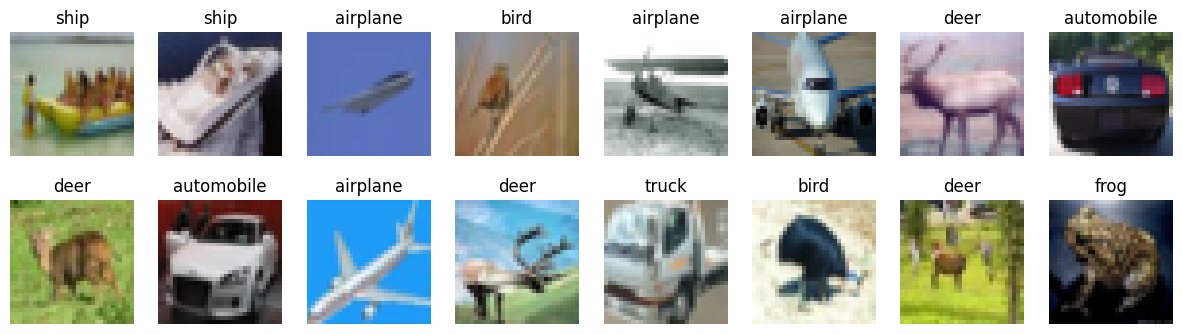

In [6]:
# show some random images from train, and their labels

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index]])
plt.show()

In [7]:
# normalize inputs
# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
# x_train = x_train.astype(np.float64) - 0.5

y_train = keras.utils.to_categorical(y_train, num_classes=10)

y_val = keras.utils.to_categorical(y_val, num_classes=10)

y_test = keras.utils.to_categorical(y_test, num_classes=10)

In [8]:
# import necessary building blocks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization, Input
from tensorflow.keras.layers import LeakyReLU

In [14]:
def make_model():
    """
    Define your model architecture here.
    Returns `Sequential` model.
    """

    model = Sequential()



    ### STUDENT CODE HERE ###
    ### --> Build your convolutional neural network.
    #
    ### First, make a CNN layer with some small kernels to learn some basic features, with Conv2D.

    model.add(Input(shape = (32,32,3)))
    model.add(keras.layers.RandomFlip("horizontal"))

    model.add(Conv2D(32, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2, 2))

    model.add(Conv2D(124, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(Conv2D(128*2, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.2))

    #model.add(Conv2D(128*2, (3,3), activation='relu', padding='same'))
    model.add(Flatten())

    model.add(Dense(128*2, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(NUM_CLASSES))

    ### Then, add a Pooling layer to pick up the relevant kernels.
    ### Then, Flatten it and add some fully-connected (Dense) normal NN layers,
    ###  to learn the relevant combinations of low-level kernel features.
    ### Finally, some regularisation is advised, using a Dropout layer, to avoid local minima.
    ### Make sure the output is of the same shape as the number of labels we have,
    ### And the input is the same as the figures (which now have a 3rd dimension - color!)
    ### Again, use google to find information on these classes.


    ### END STUDENT CODE ###

    # Ensure normalized probabilities over the 10 classes
    model.add(Activation("softmax"))

    return model

In [15]:
### STUDENT CODE HERE ###
### --> change the parameters below to perform a better training


lr = 3e-4  # initial learning rate
batch = 64
EPOCHS = 30

K.clear_session()  # clear default graph
                # don't call K.set_learning_phase() !!! (otherwise will enable dropout in train/test simultaneously)
model = make_model()  # define our model
model.compile(
                    loss='categorical_crossentropy',  # we train 10-way classification
                    optimizer=keras.optimizers.Adamax(learning_rate=lr),  # for SGD.
                    metrics=['accuracy']  # report accuracy during training
                )

for BATCH_SIZE in [64, 128, 256, 128, 64]:
    INIT_LR = lr * (BATCH_SIZE / batch)  # scale LR with batch
        # prepare model for fitting (loss, optimizer, etc)

    model.optimizer.learning_rate.assign(INIT_LR)

    lr_scheduler = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, restore_best_weights=True)

        # fit model
    model.fit(
                x_train, y_train,  # prepared data
                batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                shuffle=True,
                callbacks=[lr_scheduler, early_stop]
                )

        # save weights to file to avoid re-training
    model.save_weights("myweights.weights.h5")



Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.1756 - loss: 2.3100 - val_accuracy: 0.3090 - val_loss: 1.8683 - learning_rate: 3.0000e-04
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.3228 - loss: 1.8992 - val_accuracy: 0.4055 - val_loss: 1.6548 - learning_rate: 3.0000e-04
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.4089 - loss: 1.6702 - val_accuracy: 0.4384 - val_loss: 1.5671 - learning_rate: 3.0000e-04
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.4708 - loss: 1.5050 - val_accuracy: 0.5297 - val_loss: 1.3388 - learning_rate: 3.0000e-04
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5132 - loss: 1.3978 - val_accuracy: 0.5066 - val_loss: 1.3884 - learning_rate: 3.0000e-04
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5564 - loss: 1.2737 - val_accuracy: 0.5786 - val_loss: 1.1943 - learning_rate: 3.0000e-04
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/ste

In [11]:
# load weights from file (can call without model.fit)
model.load_weights("myweights.weights.h5")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step


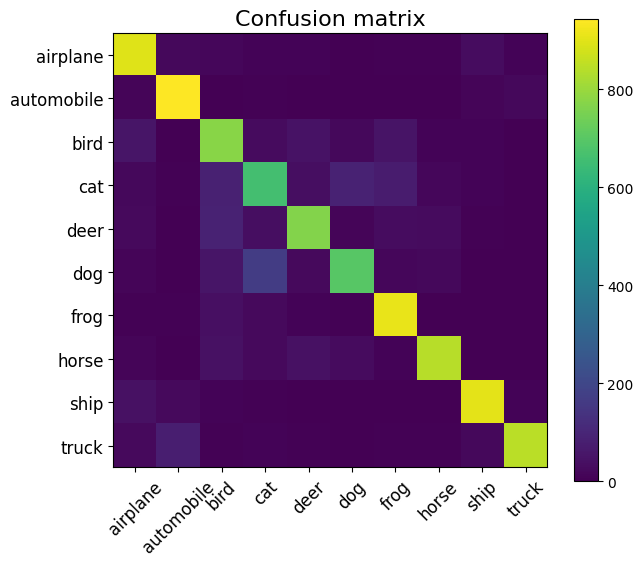

Test accuracy: 0.8243


In [16]:
# make test predictions
y_pred_test = model.predict(x_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)
y_test_index = [list(onehot).index(1) for onehot in y_test]

# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test_index, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test_index, y_pred_test_classes))

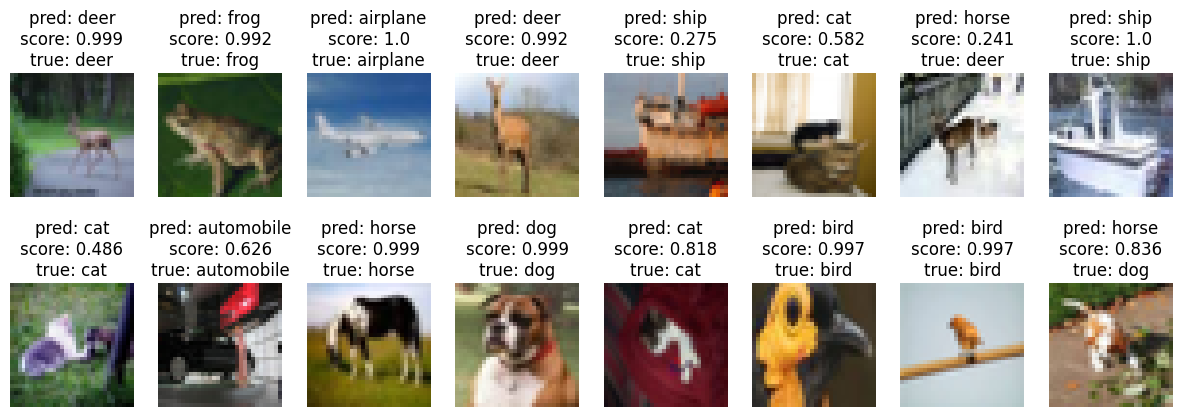

In [17]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test_index[random_index]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()

# Some tips on how to improve:

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.

## Potential grading:
* starting at zero points
* +2 for describing your iteration path in a report below.
* +2 for building a network that gets above 20% accuracy
* +1 for beating each of these milestones on __TEST__ dataset:
    * 50% (5 total)
    * 60% (6 total)
    * 65% (7 total)
    * 70% (8 total)
    * 75% (9 total)
    * 80% (10 total)

## Bonus points
Common ways to get bonus points are:
* Get higher score, obviously.
* Anything special about your NN. For example \"A super-small/fast NN that gets 80%\" gets a bonus.
* Any detailed analysis of the results. (saliency maps, whatever)


## Tips on what can be done:

 * __Network size__
   * More neurons,
   * More layers, ([lasagne docs](http://lasagne.readthedocs.org))
   * Nonlinearities in the hidden layers
   * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

 * __Convolution layers__
   * they __are a must__ unless you have any super-ideas
   * `network = lasagne.layers.Conv2DLayer(prev_layer,`
     `                       num_filters = n_neurons,`
     `                       filter_size = (filter width, filter height),`
     `                       nonlinearity = some_nonlinearity)`
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment to try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   * Plenty other layers and architectures
     * http://lasagne.readthedocs.org/en/latest/modules/layers.html
     * batch normalization, pooling, etc


 * __Early Stopping__
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum


 * __Faster optimization__ -
   * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (lasagne.layers.batch_norm) FTW!


 * __Regularize__ to prevent overfitting
   * Add some L2 weight norm to the loss function, theano will do the rest
     * Can be done manually or via - http://lasagne.readthedocs.org/en/latest/modules/regularization.html
   * Dropout - to prevent overfitting
     * `lasagne.layers.DropoutLayer(prev_layer, p=probability_to_zero_out)`   
     * Don't overdo it. Check if it actually makes your network better


 * __Data augmentation__ - getting 5x as large dataset for free is a great deal
   * Zoom-in+slice = move
   * Rotate+zoom(to remove black stripes)
   * any other perturbations
   * Add Noize (easiest: GaussianNoizeLayer)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.




# What I did:
To test the system I used different combinations of conv2d and Dense. I realised that going from filter 32 up the system begins to become more and more complex. This, from what I saw made the process slower and slower but also the machine became more precise before overlearning.

After I made a simple system I started testing with different learning rates and batch sizes. Using foor loops I made a code that runs through different learning rates and batches, all for 10 epochs, and put all the data in a csv.

The system started at 1e-4 and went to 1e-3 and batch size from 63 to 256. To take the data I made a filter that ignored everything under 0.6.

The data and a plot are presented below. (The plots were made using R, out of convenience)

From here I realised that 64 and 128 are the best options. And I choose 3e-4 for my learning rate and added the lr_scheduler. This gave me the possibility of the code to adapt but start at a very good point.

Then I realised, if I combine batch sizes I can get even more learning without overlearning so I made a for loop that changes teh batch size. I also made it so it will change th learning rate based on the batch size so to be make the system even more complex.

To be able to skip if the machine started platowing I added an early_stop.

After that part was done I went back to the model. I added Dropouts and poolings. From my experience dropouts made the machine less accurate so I deleted some of them and made the rest small so not to affect the system that much. With the pooling I did not experiment a lot. I just left it at 2 by 2 and it worked decently.

The at the end I added RandomFlip. I did not have a lot of time to test it and I am not sure if it have an impact on the code but I left it there.


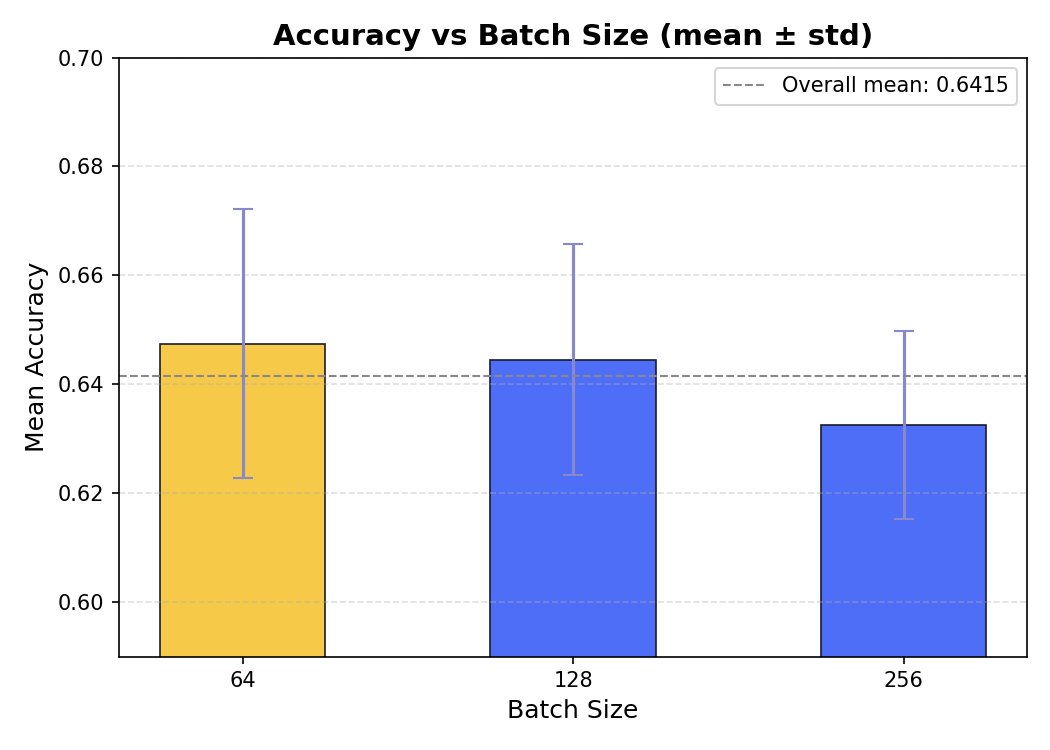

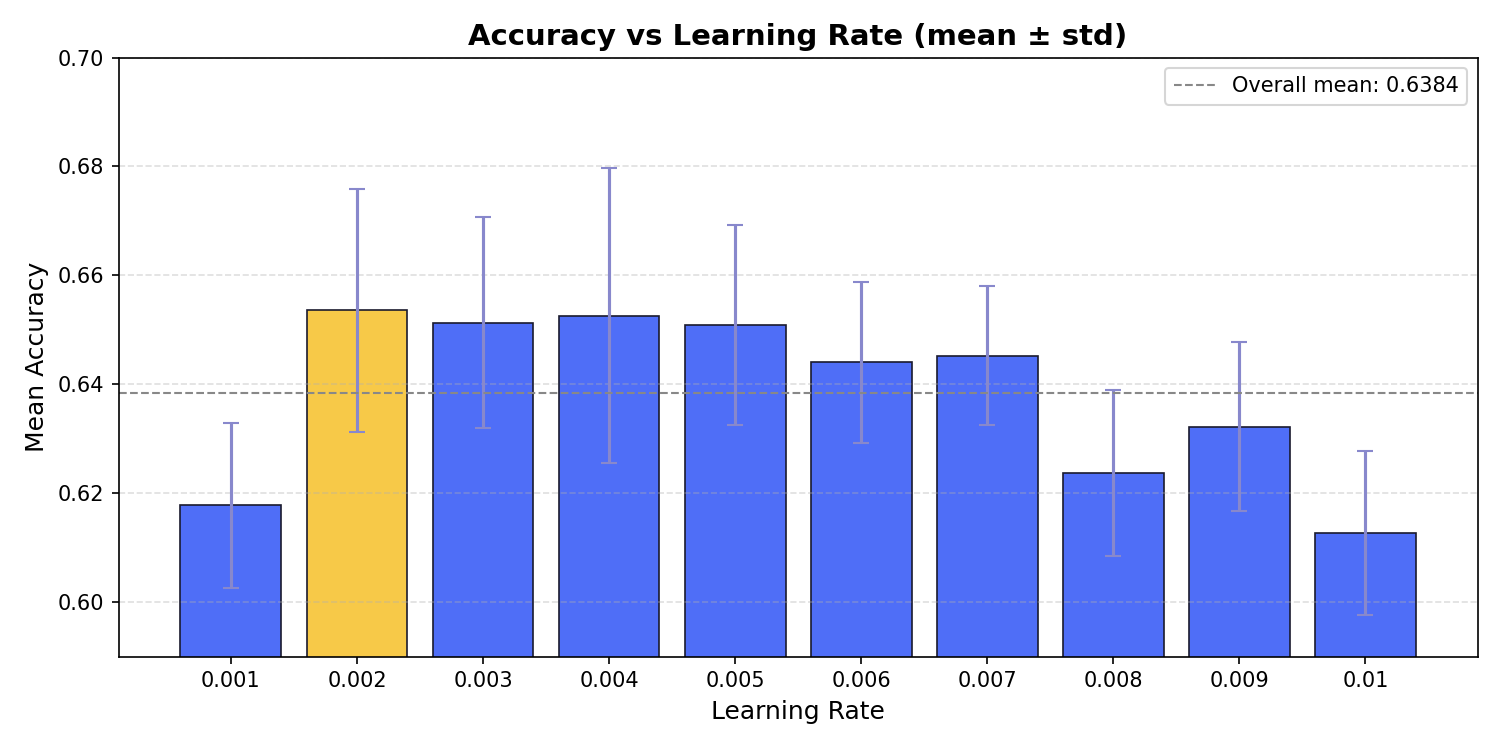

acc,lrn,btch_sz,epoch

0.6427, 0.001, 64, 10

0.627, 0.001, 64, 10

0.6032, 0.001, 64, 10

0.612, 0.001, 128, 10

0.6039, 0.001, 128, 10

0.6813, 0.002, 64, 10

0.6842, 0.002, 64, 10

0.6695, 0.002, 64, 10

0.6132, 0.002, 64, 10

0.6642, 0.002, 64, 10

0.6389, 0.002, 128, 10

0.6312, 0.002, 128, 10

0.6541, 0.002, 128, 10

0.6455, 0.002, 128, 10

0.6708, 0.003, 64, 10

0.6639, 0.003, 64, 10

0.6387, 0.003, 64, 10

0.6756, 0.003, 64, 10

0.6695, 0.003, 64, 10

0.6571, 0.003, 128, 10

0.6116, 0.003, 128, 10

0.64, 0.003, 128, 10

0.6713, 0.003, 128, 10

0.6649, 0.003, 128, 10

0.6286, 0.003, 256, 10

0.6328, 0.003, 256, 10

0.6423, 0.003, 256, 10

0.6117, 0.004, 64, 10

0.6763, 0.004, 64, 10

0.6751, 0.004, 64, 10

0.6846, 0.004, 64, 10

0.6685, 0.004, 64, 10

0.645, 0.004, 128, 10

0.6708, 0.004, 128, 10

0.6602, 0.004, 128, 10

0.6088, 0.004, 128, 10

0.6647, 0.004, 256, 10

0.6129, 0.004, 256, 10

0.6513, 0.005, 64, 10

0.6537, 0.005, 64, 10

0.6645, 0.005, 64, 10

0.6424, 0.005, 64, 10

0.6668, 0.005, 128, 10

0.6746, 0.005, 128, 10

0.6611, 0.005, 128, 10

0.6656, 0.005, 128, 10

0.6091, 0.005, 256, 10

0.649, 0.005, 256, 10

0.6511, 0.005, 256, 10

0.6208, 0.005, 256, 10

0.6486, 0.006, 64, 10

0.6394, 0.006, 64, 10

0.6578, 0.006, 64, 10

0.6426, 0.006, 64, 10

0.6554, 0.006, 128, 10

0.6641, 0.006, 128, 10

0.6601, 0.006, 128, 10

0.6363, 0.006, 256, 10

0.6103, 0.006, 256, 10

0.6385, 0.006, 256, 10

0.6314, 0.006, 256, 10

0.6433, 0.007, 64, 10

0.6525, 0.007, 64, 10

0.6219, 0.007, 64, 10

0.6341, 0.007, 64, 10

0.6398, 0.007, 128, 10

0.6624, 0.007, 128, 10

0.6605, 0.007, 128, 10

0.6331, 0.007, 128, 10

0.646, 0.007, 256, 10

0.659, 0.007, 256, 10

0.621, 0.008, 64, 10

0.6147, 0.008, 64, 10

0.6059, 0.008, 64, 10

0.6214, 0.008, 128, 10

0.6463, 0.008, 128, 10

0.6221, 0.008, 256, 10

0.6351, 0.008, 256, 10

0.646, 0.008, 256, 10

0.6008, 0.008, 256, 10

0.6492, 0.009, 128, 10

0.616, 0.009, 128, 10

0.6287, 0.009, 128, 10

0.6434, 0.009, 256, 10

0.6089, 0.009, 256, 10

0.6471, 0.009, 256, 10

0.6005, 0.01, 64, 10

0.6051, 0.01, 128, 10

0.6384, 0.01, 256, 10

0.6067, 0.01, 256, 10